<a href="https://colab.research.google.com/github/YefridC09/ST-554_Big_data_analysis/blob/main/HW5_Yefrid__Cordoba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 5 - ST-554**

# Author: **Yefrid Cordoba**

## Part I - Concepts

### 1

In the manufacturing of paper, there are sensors across the paper machine that register data over time, having a big **Volume** of data that continuously is streamed (**Velocity**), this data can be of different types like temperature, flows, pressures, refining energy, basis weight, moisture, strength, speed, etc (**Variety**). As there is always variability in phenomena that cannot be controlled during the process (Heterogeneity of the fibers, equipment malfunction, etc.), the uncertainty needs to be considered in this type of data(**Veracity**). Analyzing data from paper machine operations can be used to predict important product parameters, such as paper strength or productivity, which will help us avoid downtime and product rejections due to quality compliance (**Value**).

### 2

First it is necessary to load the module `sqlite3` and make the connection to the .sqlite file (the file needs to be uploaded to the main folder)

In [49]:
#Import the modules
import sqlite3
import pandas as pd

#Connectin to the .sqlite file
MLB = sqlite3.connect("lahman_1871-2022.sqlite")

I will create a helper function for the querys execution.

In [50]:
def execute_query(connection, query):
    cursor = connection.cursor()
    try:
        cursor.execute(query)
        print("Query executed successfully")
        #connection.commit()
    except sqlite3.Error as e:
        print(f"The error '{e}' occurred")
    cursor.close()

For the creation of a new table, first it is necessary to create a cursor, generate the SQL, execute the SQL code, and finally close the cursor.

A new table will be neccesary when a new set of related statistics needs to be added to the database.

In [51]:
#Write the SQL to create a new table that contains the points for each game for both of the team
nt = """
    CREATE TABLE IF NOT EXISTS recent_final (
        LA_dodgers INT,
        T_BlueJays INT);
"""
#execute the SQL code
execute_query(MLB,nt)

Query executed successfully


Checking if the code worked

In [52]:
pd.read_sql('''
        SELECT *
        FROM recent_final;
        ''', MLB)

,LA_dodgers,T_BlueJays


Now it is necessary to create a query that will add the rows to the table, the code is executed, and the table is shown.

In [53]:
#Create the query to insert the data
c_rows = """
        INSERT INTO recent_final (LA_dodgers, T_BlueJays)
        VALUES
            (4, 11),
            (5, 1),
            (6, 5),
            (2, 6),
            (1, 6),
            (3, 1)
"""

#Executing the query
execute_query(MLB, c_rows)

#Showing the table
pd.read_sql('''
        SELECT *
        FROM recent_final;
        ''', MLB)

Query executed successfully


,LA_dodgers,T_BlueJays
0,4,11
1,5,1
2,6,5
3,2,6
4,1,6
5,3,1


In [54]:
create_row = """
       INSERT INTO
           recent_final (LA_dodgers)
       VALUES
           (5);
"""

execute_query(MLB, create_row)

Query executed successfully


In [55]:
#Showing the table
pd.read_sql('''
        SELECT *
        FROM recent_final;
        ''', MLB)

,LA_dodgers,T_BlueJays
0,4,11.0
1,5,1.0
2,6,5.0
3,2,6.0
4,1,6.0
5,3,1.0
6,5,NaN


Now we update the data with the missing value.
As data is coming in over time to the database (games that are being played), the data needs to be constantly updated by adding rows to the database.

In [56]:
mod_row = """
    UPDATE recent_final
    SET T_BlueJays = 4
    WHERE (T_BlueJays is null);
"""

execute_query(MLB, mod_row)

#Showing the table
pd.read_sql('''
        SELECT *
        FROM recent_final;
        ''', MLB)

Query executed successfully


,LA_dodgers,T_BlueJays
0,4,11
1,5,1
2,6,5
3,2,6
4,1,6
5,3,1
6,5,4


Now we delete the rows where the points are greater than 6

In [57]:
del_row = """
    DELETE FROM recent_final
    WHERE LA_dodgers > 6 OR T_BlueJays > 6
    """

execute_query(MLB, del_row)

#Showing the table
pd.read_sql('''
        SELECT *
        FROM recent_final;
        ''', MLB)

Query executed successfully


,LA_dodgers,T_BlueJays
0,5,1
1,6,5
2,2,6
3,1,6
4,3,1
5,5,4


Finally, the created table will be removed from the database

In [58]:
d_table = """
    DROP TABLE recent_final;
"""

execute_query(MLB, d_table)

Query executed successfully


In order to read the data we get the schema.
Reading the data is one of the most important tasks for us, as we will need the information from the tables to perform the analysis.

In [59]:
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''

# creating a dataframe with the schema
schema_MLB = pd.read_sql(get_schema, MLB)
schema_MLB

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


The data is read using `pd.read_sql()`

In [60]:
#Reading the data from table AllstarFull
pd.read_sql('SELECT * FROM AllstarFull', MLB)

,playerID,yearID,gameNum,gameID,teamID,lgID,GP,startingPos
0,gomezle01,1933,0,ALS193307060,NYA,AL,1,1
1,ferreri01,1933,0,ALS193307060,BOS,AL,1,2
2,gehrilo01,1933,0,ALS193307060,NYA,AL,1,3
3,gehrich01,1933,0,ALS193307060,DET,AL,1,4
4,dykesji01,1933,0,ALS193307060,CHA,AL,1,5
...,...,...,...,...,...,...,...,...
5511,rileyau01,2022,0,NLS202207190,ATL,NL,1,None
5512,schwaky01,2022,0,NLS202207190,PHI,NL,1,None
5513,sotoju01,2022,0,NLS202207190,WAS,NL,1,None
5514,swansda01,2022,0,NLS202207190,ATL,NL,1,None


### 3

The `HAVING` clause is important when a condition stated after this clause needs to be meet when using the `GROUP BY`. It is an optional clause for the `SELECT` statement. `HAVING` always needs to be used after `GROUP BY`. This clause can be used to make SQL joins with conditional filtering.

## Part II - Simulation of a sampling distribution

### 4

The code from the HW5 document

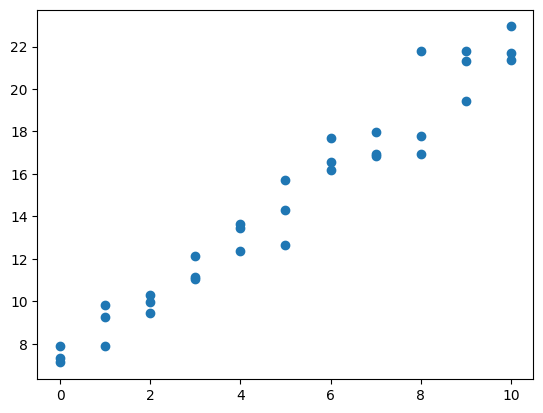

In [61]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
import sklearn as sk
from numpy.random import default_rng
from scipy.stats import percentileofscore

#create a random number generator
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()

As an example of what we have to repeat 5000 times, the next block will generate the slope for the above data.

In [62]:
reg = sk.linear_model.LinearRegression()
reg.fit(x.reshape(-1,1), y)
print(reg.intercept_, reg.coef_)

7.259043801350283 [1.47450564]


Now we have to repeat the process 5000 times using a for loop

In [78]:
#First an object is created to store the slopes
slopes = []

#The loop will iterate and generate 5000 slopes for the data
for i in range(5000):
    beta_0 = 7
    beta_1 = 1.5
    # get three 'values' of x at each integer from 0 to 10.
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
    n = 33
    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    reg = sk.linear_model.LinearRegression()
    reg.fit(x.reshape(-1,1), y)
    #print(reg.intercept_, reg.coef_)
    slopes.append(reg.coef_[0])


The next step is to generate a histogram of the slopes

<Axes: ylabel='Frequency'>

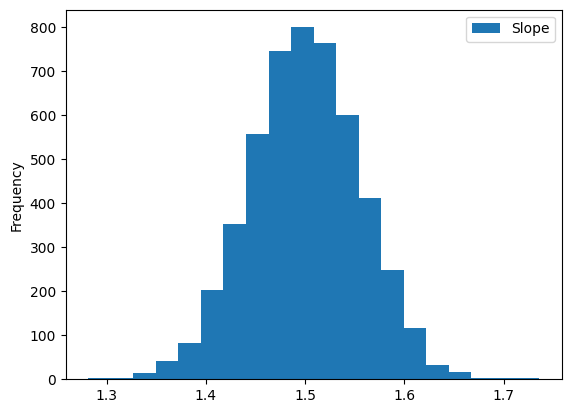

In [64]:
#First we turn into a data frame to use .plot
slopes = pd.DataFrame(slopes, columns = ['Slope'])
slopes.plot.hist(bins = 20)

The histogram above contains the randomly generated slopes with a mean value of 1.5. Now, we need to evaluate the probability of observing a sample slope larger than 1.65.

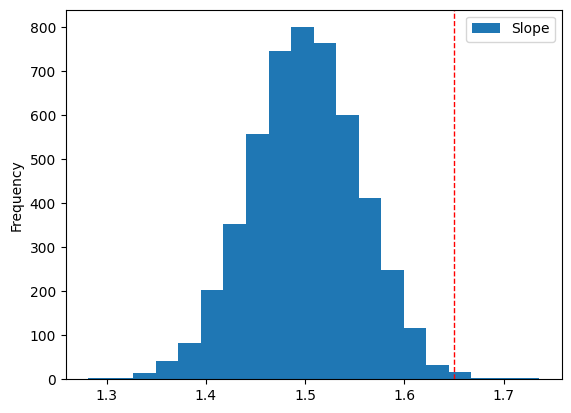

In [65]:
slopes = pd.DataFrame(slopes, columns = ['Slope'])
slopes.plot.hist(bins = 20)
plt.axvline(1.65, color='red', linestyle='dashed', linewidth=1)

It is necessary to calculate from the generated slopes the percentage of data that are larger than 1.65(to the right of the red dashed line), this will be the probability of observing sa sample slope larger than 1.65.

The function `percentileofscore` from the `scipy` module will calculate this value; however, defining the `kind = 'weak' will estimate the values that are lower than or equal to the specified value. We need to calculate the 1-percentile to find the value we are looking for.

In [66]:
#Calculate the proportion of simulated values that are larger than 1.65
percentile_rank = 1 - (percentileofscore(list(slopes['Slope']), 1.65, kind='weak')/100)
print(percentile_rank)
percentile_rank = round(percentile_rank*100, 3)
print(f'Assuming that the true slope is 1.5, the probability of getting a sample slope that is larger of 1.65 is about {percentile_rank} %.')

0.0037999999999999146
Assuming that the true slope is 1.5, the probability of getting a sample slope that is larger of 1.65 is about 0.38 %.


This is important for us to determine and conclude whether a calculated slope is close to an assumed true value after setting an especified $\alpha$ value from which we are going to do the hypothesis test.

## Part III - Big data examples & rare events

### 5

Amazon's model filtering resumes of potential candidates for positions in the company is an example of implicit bias in the model. This is because, from the beginning, the data used to train the model was favoring the selection of male candidates, reproducing the inequality in the hiring process for males and females candidates.

This can be solved by making the model disregard words that are related to the gender or sex of the applicants, to make sure that this does not generate biased results when the model is being applied.

### 6

For surface hydrology modelling, it is necessary to compile large amounts of data on surface waters (rivers, lakes, reservoirs, streams, and wetlands), their boundaries, and flow accumulation. These models aim to provide information on the flow, quantity, and potential risks that water bodies might generate in the future. For this objective, digital elevation models are used to create a globally consistent, high-resolution digital hydrographic map of the globe.

The resolution of the data might impose a limitation on the predictive power of the models, however, this comes with the cost that a larger amount of data will need to be collected for example to go from 10-m resolution, to a 2-m resolution to more accuratelly include streams that are less than 10-m, but contribute significantlly to the overall water suppply in an especific are, or to an increased risk of flood

### 7

In the bleaching process for bleached paper, 90% of the time, chlorine dioxide is used as the bleaching agent. This poisonous and explosive gas is dissolved in water and continuously used in large quantities. Even when rare, there have been a few events in which leakage or explosion due to a sudden pressure increase has posed a risk to people and caused millions of dollars in losses. It is important to understand the rare events to be prepared in case this happens and causes loss of life.

## Part IV - Querying a database

### 8

The connection was made above (see Part I- question 2).

Below is shown a dataframe with all the tables in the database.

In [67]:
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''

# creating a dataframe with the schema
schema_MLB = pd.read_sql(get_schema, MLB)
schema_MLB

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


### 9

From the table Teams, we need to filter on the `yearID` column where the year is equal to 2015, and then we apply that query to the `MLB` database to get the data.

In [68]:
#First we create an SQL query to select all the columns from the table Teams where year is 2015
T_2015 ="""
    SELECT *
    FROM Teams
    WHERE yearID = 2015

    """

#We apply the query to the function pd.read_sql() to get a dataframe with the data
pd.read_sql(T_2015, MLB)


,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


### 10

First we are going to see the `HallOfFame` table.

In [69]:
#We use the function read_sql() to read the table
pd.read_sql('SELECT * FROM HallOfFame', MLB)


,playerID,yearid,votedBy,ballots,needed,votes,inducted,category,needed_note
0,aaronha01,1982,BBWAA,415.0,312.0,406.0,Y,Player,None
1,abbotji01,2005,BBWAA,516.0,387.0,13.0,N,Player,None
2,abreubo01,2020,BBWAA,397.0,298.0,22.0,N,Player,None
3,abreubo01,2021,BBWAA,401.0,301.0,35.0,N,Player,None
4,abreubo01,2022,BBWAA,394.0,296.0,34.0,N,Player,None
...,...,...,...,...,...,...,...,...,...
4318,zambrca01,2018,BBWAA,422.0,317.0,0.0,N,Player,None
4319,zeileto01,2010,BBWAA,539.0,405.0,0.0,N,Player,None
4320,zimmech01,1938,BBWAA,262.0,197.0,1.0,N,Player,None
4321,ziskri01,1989,BBWAA,447.0,336.0,0.0,N,Player,None


Now the columns that i want as an output are: `playerID, yearid, category`, filtering the values when the column `inducted` is `'Y'`.

In [70]:
#Creating the query
HOF = """
    SELECT playerID, yearid, category
    FROM HallOfFame
    WHERE inducted = 'Y'
    """

#Executing the query
pd.read_sql(HOF, MLB)

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


### 11

First we need to use `SELECT DISTINCT` to remove all the duplicates values in the `playerID` column, `FROM` the `Managers` table, `WHERE` the `teamID` is the Pittsburgh Pirates `PIT`.

In [71]:
#Query
UM = """
    SELECT DISTINCT playerID
    FROM Managers
    WHERE teamID = 'PIT'
    """
#Executing the query
pd.read_sql(UM, MLB)

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


### 12

We need to create an `INNER JOIN` on the `playerID` for `Managers` and `HallOfFame` tables, then they will be filtered `WHERE` the column `inducted` is `Y`.

In [72]:
HMI = """
    SELECT DISTINCT Managers.playerID, HallOfFame.inducted
    FROM Managers
    INNER JOIN HallOfFame ON Managers.playerID = HallOfFame.playerID
    WHERE HallOfFame.inducted = 'Y'
    """
managers = pd.read_sql(HMI, MLB)
managers

,playerID,inducted
0,alstowa01,Y
1,andersp01,Y
2,ansonca01,Y
3,applilu01,Y
4,baineha01,Y
...,...,...
92,willidi02,Y
93,willite01,Y
94,wrighge01,Y
95,wrighha01,Y


The table above shows the players (or managers) who were inducted into the Hall of Fame and served as team managers.

Below, the number of such people is shown using the function `len()`.

In [73]:
len(managers)

97

The number of people who were team managers and were inducted in the hall of fame is 97.

### 13

To do this, we use the same query from the previous item, but removing the `DISTINCT` clause. and including the columns `G, L, W`

In [74]:
#Creating the query
GLW = """
    SELECT Managers.playerID, G, L, W
    FROM Managers
    INNER JOIN HallOfFame ON Managers.playerID = HallOfFame.playerID
    WHERE inducted = 'Y'
    """
#Executing the query and saving the output in an object
games = pd.read_sql(GLW, MLB)
games

,playerID,G,L,W
0,alstowa01,154,62,92
1,alstowa01,154,55,98
2,alstowa01,154,61,93
3,alstowa01,154,70,84
4,alstowa01,154,83,71
...,...,...,...,...
991,wrighha01,46,23,22
992,wrighha01,138,69,68
993,wrighha01,155,66,87
994,wrighha01,133,57,72


Now that the table is saved as a DataFrame, a new table will be created with the sum of wins and losses for each manager, and the ratio will be calculated.

In [75]:
rat = games.groupby('playerID').sum()
rat['ratio'] = rat['W']/rat['L']
rat

,G,L,W,ratio
playerID,,,,
alstowa01,3658,1613,2040,1.264724
andersp01,4030,1834,2194,1.196292
ansonca01,2288,947,1296,1.368532
applilu01,40,30,10,0.333333
baineha01,4,3,1,0.333333
...,...,...,...,...
willidi02,3023,1451,1571,1.082702
willite01,637,364,273,0.750000
wrighge01,85,25,59,2.360000


Next, a new column is added to calculate the win/loss percentage, taking the `W/(W+L)`.

In [76]:
rat['W_L_per'] = rat['W']/(rat['L']+rat['W'])
rat

,G,L,W,ratio,W_L_per
playerID,,,,,
alstowa01,3658,1613,2040,1.264724,0.558445
andersp01,4030,1834,2194,1.196292,0.544687
ansonca01,2288,947,1296,1.368532,0.577798
applilu01,40,30,10,0.333333,0.250000
baineha01,4,3,1,0.333333,0.250000
...,...,...,...,...,...
willidi02,3023,1451,1571,1.082702,0.519854
willite01,637,364,273,0.750000,0.428571
wrighge01,85,25,59,2.360000,0.702381


Finally, the table is sorted based on the `W_L_per`, from largest to smallest.

In [77]:
rat.sort_values('W_L_per', ascending = False)

,G,L,W,ratio,W_L_per
playerID,,,,,
simmote01,1,0,1,inf,1.000000
wrighge01,85,25,59,2.360000,0.702381
spaldal01,126,47,78,1.659574,0.624000
mccarjo99,3487,1333,2125,1.594149,0.614517
comisch01,1410,541,840,1.552680,0.608255
...,...,...,...,...,...
bottoji01,78,56,21,0.375000,0.272727
applilu01,40,30,10,0.333333,0.250000
baineha01,4,3,1,0.333333,0.250000


Based on the percentage, the manager with the highest win/loss percentage, given a representative number of games, is `mccarjo99`.

Above that percentage, the number of games that the others had is no more than 1 season (154 games).